# ⚖️ Conflict of Interest Screening & Risk Assessment
## Professional Services Engagements — Independence & Ethics Compliance

**Objective:** Conduct systematic conflict-of-interest (COI) screening for 36 simulated audit and consulting client engagements — applying the IESBA five-threat framework to identify independence risks, assign risk ratings, and produce management-ready summaries.

**Regulatory Frameworks:** IESBA Code of Ethics · IFAC Independence Standards · PCAOB Rule 3520  
**Tools:** Python · Pandas · Matplotlib · Seaborn · Risk Scoring Engine

> *All client data is synthetic and created solely for portfolio demonstration purposes.*

---


## 1. Setup & Engagement Register

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid')

RISK_COLORS   = {'Low':'#3BAB6F','Medium':'#F39C12','High':'#E8834D','Critical':'#E74C3C'}
STATUS_COLORS = {'Cleared':'#3BAB6F','Escalated':'#E74C3C','In Review':'#F39C12',
                 'Pending Info':'#2D6A9F','Closed - Declined':'#34495E'}
PALETTE = ['#2D6A9F','#E74C3C','#3BAB6F','#F39C12','#9B59B6','#1ABC9C','#E8834D','#34495E']

np.random.seed(42)

data = [
  ("Meridian Capital Group","Financial Services","Audit",4200000,True,False,False,False,True,3,"Cleared","Analyst A"),
  ("Titan Infrastructure Ltd","Construction","Consulting",850000,False,True,False,False,False,5,"Escalated","Analyst B"),
  ("BlueSky Pharmaceuticals","Healthcare","Audit",3100000,False,False,True,False,False,2,"Cleared","Analyst A"),
  ("Vertex Logistics Corp","Logistics","Tax Advisory",620000,True,False,False,False,True,7,"Escalated","Analyst C"),
  ("Orion Real Estate Fund","Real Estate","Audit",2800000,False,False,False,True,False,4,"In Review","Analyst B"),
  ("NovaTech Solutions","Technology","Consulting",430000,False,False,True,False,False,1,"Cleared","Analyst A"),
  ("Coastal Energy Partners","Energy","Audit",5500000,True,True,False,False,True,8,"Escalated","Analyst C"),
  ("Pinnacle Retail Holdings","Retail","Tax Advisory",290000,False,False,False,False,False,2,"Cleared","Analyst B"),
  ("Stratosphere Aviation","Aviation","Consulting",760000,False,True,False,True,False,6,"Escalated","Analyst A"),
  ("GreenPath Renewables","Energy","Audit",1900000,False,False,False,False,True,3,"Cleared","Analyst C"),
  ("Monarch Insurance Group","Financial Services","Audit",3700000,True,False,True,False,False,4,"In Review","Analyst B"),
  ("Delta Biotech Inc","Healthcare","Consulting",540000,False,False,False,False,False,1,"Cleared","Analyst A"),
  ("Harbourview Capital","Financial Services","Audit",6200000,True,True,True,False,True,12,"Escalated","Analyst C"),
  ("Sunstone Property Trust","Real Estate","Tax Advisory",380000,False,False,False,False,False,2,"Cleared","Analyst B"),
  ("Alpine Manufacturing","Manufacturing","Audit",2200000,False,False,False,True,False,5,"In Review","Analyst A"),
  ("Crestline Media Group","Media","Consulting",310000,False,True,False,False,False,3,"Cleared","Analyst C"),
  ("Pacific Trade Finance","Financial Services","Audit",4800000,True,False,False,True,True,9,"Escalated","Analyst B"),
  ("Silverstone Auto Group","Automotive","Tax Advisory",220000,False,False,True,False,False,2,"Cleared","Analyst A"),
  ("Quantum Data Systems","Technology","Audit",1600000,False,False,False,False,True,3,"Cleared","Analyst C"),
  ("Fairfield Agricultural","Agriculture","Consulting",190000,False,False,False,False,False,1,"Cleared","Analyst B"),
  ("Nexus Telecommunications","Telecommunications","Audit",3300000,True,False,True,False,False,6,"In Review","Analyst A"),
  ("Ridgeway Private Equity","Financial Services","Consulting",920000,True,True,False,False,True,10,"Escalated","Analyst C"),
  ("Clearwater Utilities","Utilities","Audit",2600000,False,False,False,False,False,3,"Cleared","Analyst B"),
  ("Summit Education Group","Education","Tax Advisory",150000,False,False,False,False,False,1,"Cleared","Analyst A"),
  ("Blackrock Mining Corp","Mining","Audit",4100000,True,False,False,True,True,7,"Escalated","Analyst C"),
  ("Aurora Fashion Retail","Retail","Consulting",280000,False,True,False,False,False,4,"In Review","Analyst B"),
  ("Ironclad Cybersecurity","Technology","Audit",1100000,False,False,True,False,False,2,"Cleared","Analyst A"),
  ("Westport Shipping Lines","Logistics","Tax Advisory",470000,False,False,False,True,False,5,"In Review","Analyst C"),
  ("Goldfield Asset Management","Financial Services","Audit",5900000,True,True,True,True,True,15,"Escalated","Analyst B"),
  ("Brightside Healthcare","Healthcare","Consulting",360000,False,False,False,False,False,1,"Cleared","Analyst A"),
  ("Stonebridge Law Partners","Legal Services","Consulting",210000,False,True,False,False,False,3,"Closed - Declined","Analyst C"),
  ("Redwood Carbon Credits","Environmental","Audit",890000,False,False,False,False,True,4,"Cleared","Analyst B"),
  ("TerraFirm Construction","Construction","Tax Advisory",340000,True,False,False,False,False,2,"Cleared","Analyst A"),
  ("Celestial Hospitality","Hospitality","Audit",1700000,False,False,True,True,False,6,"Escalated","Analyst C"),
  ("Frontier Digital Ventures","Technology","Consulting",650000,False,False,False,False,False,2,"Cleared","Analyst B"),
  ("Imperium Banking Corp","Financial Services","Audit",7200000,True,True,False,True,True,14,"Escalated","Analyst A"),
]


cols = ['Client_Name','Industry','Engagement_Type','Revenue',
        'Ownership_Flag','Director_Flag','Prior_NonAudit',
        'Litigation_Flag','Related_Entity','Days_Open',
        'Status','Analyst']

df = pd.DataFrame(data, columns=cols)
df['Eng_ID']  = ['ENG-'+str(1000+i) for i in range(len(df))]
df['Screened'] = pd.date_range(start='2025-08-01', periods=len(df), freq='3D')
df['SLA_Breach'] = df['Days_Open'] > 5

print(f"Engagement Register: {len(df)} clients")
print(f"Status mix:")
print(df['Status'].value_counts())
df[['Eng_ID','Client_Name','Industry','Engagement_Type','Status','Days_Open']].head(8)


Engagement Register: 36 clients
Status mix:
Status
Cleared              18
Escalated            11
In Review             6
Closed - Declined     1
Name: count, dtype: int64


,Eng_ID,Client_Name,Industry,Engagement_Type,Status,Days_Open
0,ENG-1000,Meridian Capital Group,Financial Services,Audit,Cleared,3
1,ENG-1001,Titan Infrastructure Ltd,Construction,Consulting,Escalated,5
2,ENG-1002,BlueSky Pharmaceuticals,Healthcare,Audit,Cleared,2
3,ENG-1003,Vertex Logistics Corp,Logistics,Tax Advisory,Escalated,7
4,ENG-1004,Orion Real Estate Fund,Real Estate,Audit,In Review,4
5,ENG-1005,NovaTech Solutions,Technology,Consulting,Cleared,1
6,ENG-1006,Coastal Energy Partners,Energy,Audit,Escalated,8
7,ENG-1007,Pinnacle Retail Holdings,Retail,Tax Advisory,Cleared,2


## 2. IESBA Risk Scoring Engine

| Threat | IESBA Section | Trigger |
|---|---|---|
| Self-Interest | S.120 | Common ownership / fee dependency |
| Self-Review | S.121 | Prior non-audit services on audit client |
| Familiarity | S.124 | Common director / long association |
| Intimidation | S.125 | Active litigation |
| Advocacy | S.123 | Related entity dependency |


In [2]:
def score_self_interest(r):
    s = 0
    if r['Ownership_Flag']: s += 40
    if r['Revenue'] > 3e6:  s += 20
    if r['Revenue'] > 5e6:  s += 15
    return min(s, 100)

def score_self_review(r):
    if r['Prior_NonAudit'] and r['Engagement_Type'] == 'Audit': return 55
    if r['Prior_NonAudit']: return 25
    return 0

def score_familiarity(r):
    s = 0
    if r['Director_Flag']:  s += 45
    if r['Days_Open'] > 10: s += 10
    return min(s, 100)

def score_intimidation(r): return 70 if r['Litigation_Flag'] else 0

def score_advocacy(r):
    s = 0
    if r['Related_Entity']:  s += 35
    if r['Revenue'] > 4e6:   s += 15
    return min(s, 100)

df['S_SelfInt']  = df.apply(score_self_interest,  axis=1)
df['S_SelfRev']  = df.apply(score_self_review,    axis=1)
df['S_Familiar'] = df.apply(score_familiarity,    axis=1)
df['S_Intimid']  = df.apply(score_intimidation,   axis=1)
df['S_Advocacy'] = df.apply(score_advocacy,       axis=1)

df['Risk_Score'] = (df['S_SelfInt']*0.25 + df['S_SelfRev']*0.25 +
                    df['S_Familiar']*0.20 + df['S_Intimid']*0.20 +
                    df['S_Advocacy']*0.10).round(1)

def rating(s):
    if s >= 60: return 'Critical'
    if s >= 40: return 'High'
    if s >= 20: return 'Medium'
    return 'Low'

df['Risk_Rating'] = df['Risk_Score'].apply(rating)
df['Threat_Count'] = df[['Ownership_Flag','Director_Flag','Prior_NonAudit',
                           'Litigation_Flag','Related_Entity']].sum(axis=1)

def recommend(r):
    if r['Risk_Rating'] == 'Critical': return 'Escalate to Ethics Partner — Do not proceed without safeguards'
    if r['Risk_Rating'] == 'High':     return 'Senior Manager Review — Document safeguards; consider restructure'
    if r['Risk_Rating'] == 'Medium':   return 'Standard Review — Apply safeguards; obtain client acknowledgement'
    return 'Proceed — No material threats; file documentation'

df['Action'] = df.apply(recommend, axis=1)

print("Risk Distribution:")
print(df['Risk_Rating'].value_counts())
print()
print("Top 5 Highest Risk Engagements:")
print(df.nlargest(5,'Risk_Score')[['Eng_ID','Client_Name','Risk_Rating','Risk_Score']].to_string(index=False))


Risk Distribution:
Risk_Rating
Low         24
Medium       9
High         2
Critical     1
Name: count, dtype: int64

Top 5 Highest Risk Engagements:
  Eng_ID                Client_Name Risk_Rating  Risk_Score
ENG-1028 Goldfield Asset Management    Critical        62.5
ENG-1035      Imperium Banking Corp        High        48.8
ENG-1012        Harbourview Capital        High        48.5
ENG-1016      Pacific Trade Finance      Medium        34.0
ENG-1024      Blackrock Mining Corp      Medium        34.0


## 3. Portfolio Risk Dashboard

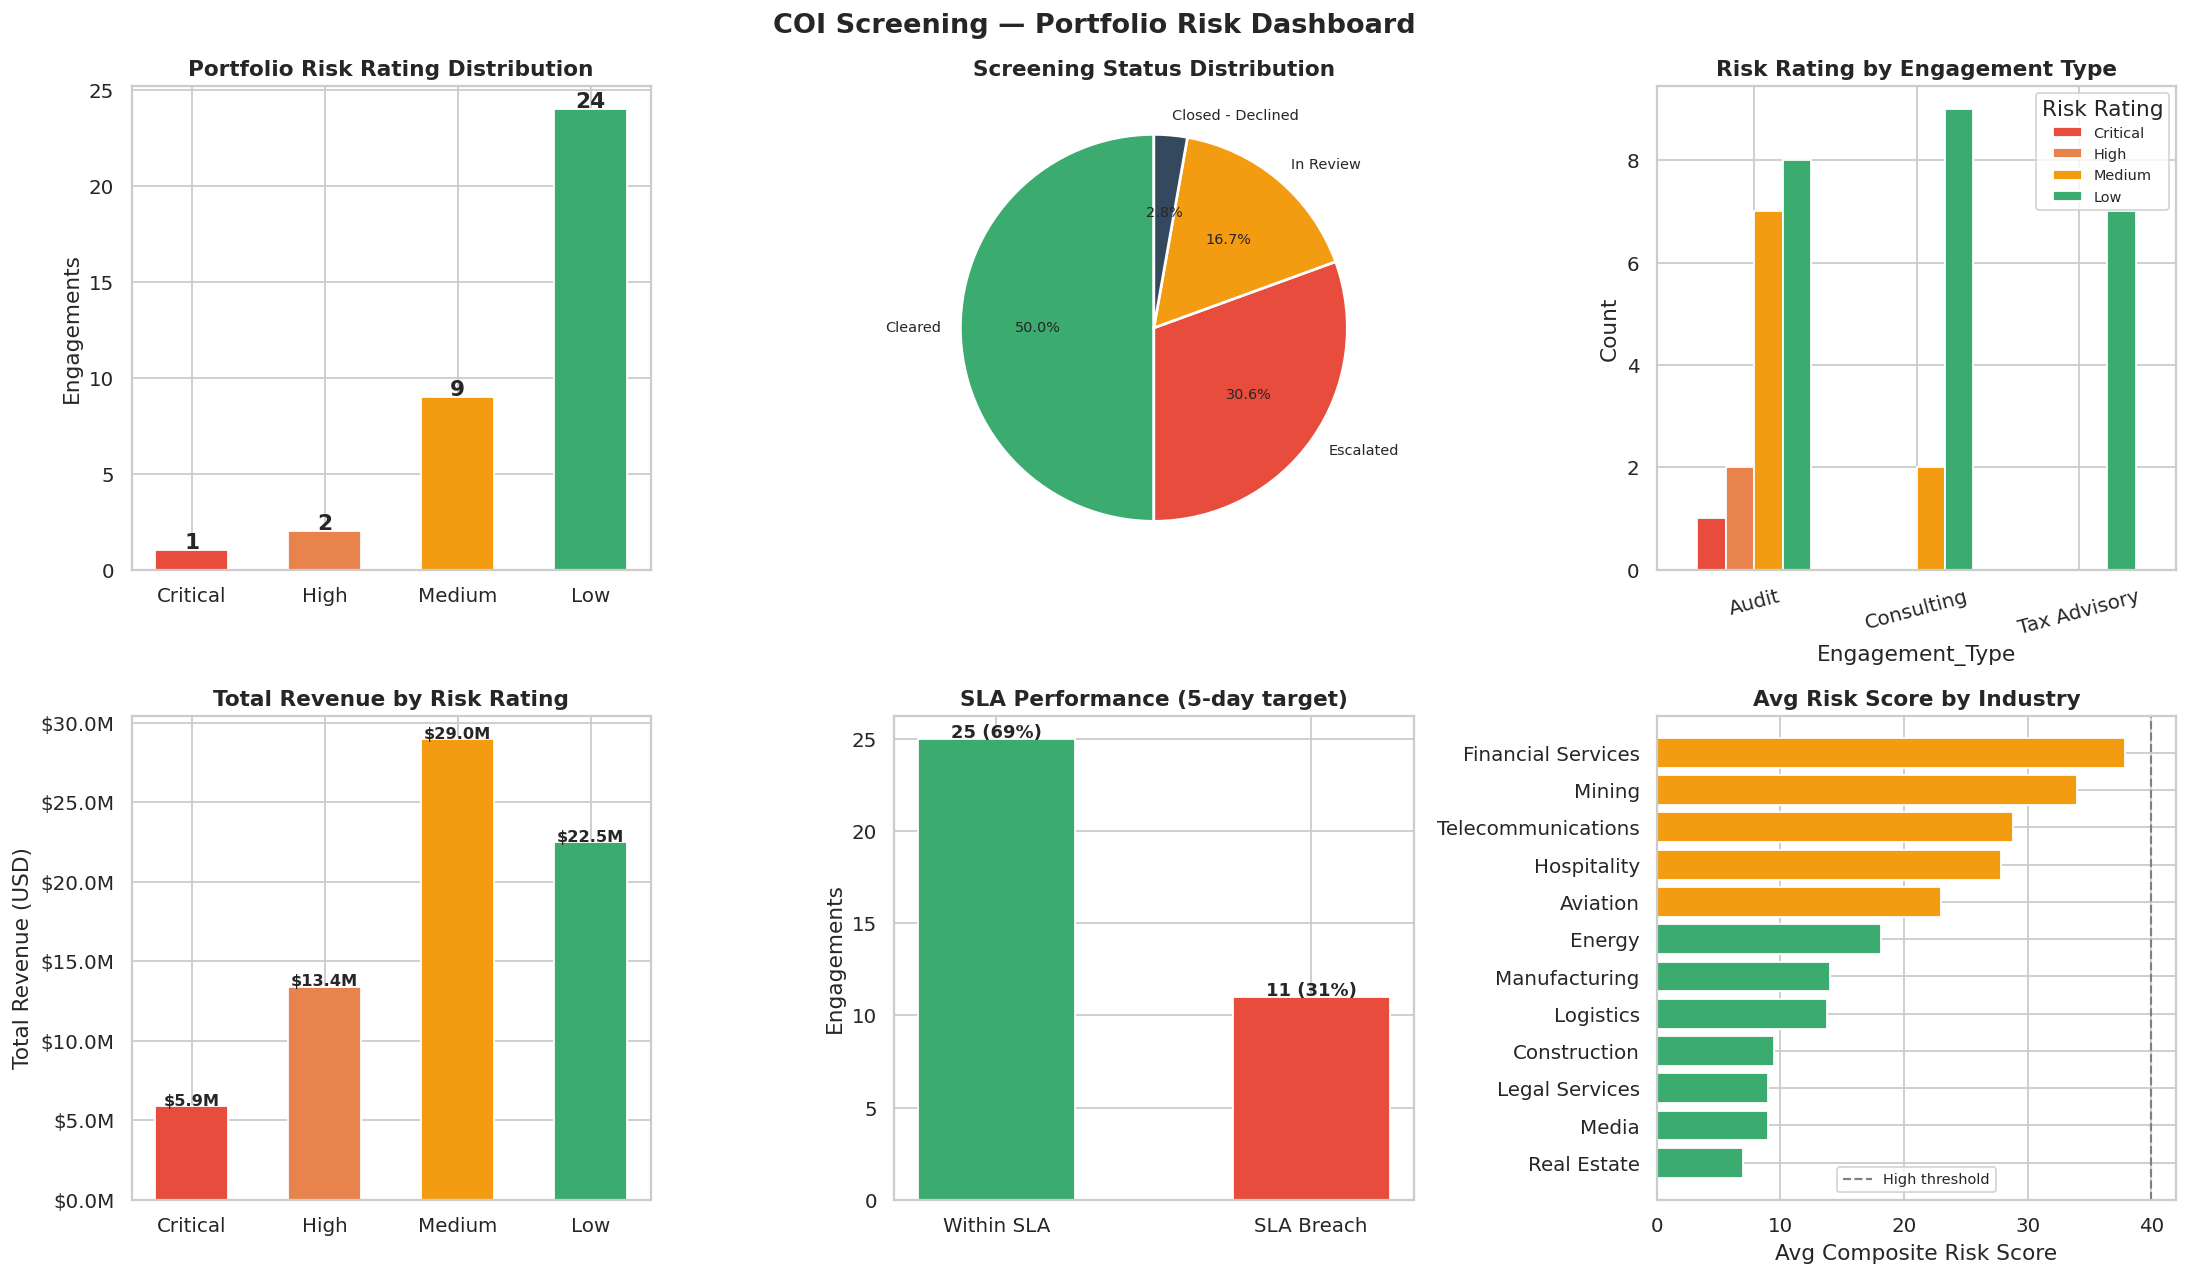

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('COI Screening — Portfolio Risk Dashboard', fontsize=15, fontweight='bold')

rating_order = ['Critical','High','Medium','Low']

# Risk distribution
ax = axes[0,0]
rc = df['Risk_Rating'].value_counts().reindex(rating_order)
bars = ax.bar(rating_order, rc.values,
              color=[RISK_COLORS[r] for r in rating_order], width=0.55, edgecolor='white')
ax.set_title('Portfolio Risk Rating Distribution', fontweight='bold')
ax.set_ylabel('Engagements')
for bar, val in zip(bars, rc.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            str(val), ha='center', fontsize=12, fontweight='bold')

# Status breakdown
ax = axes[0,1]
sc = df['Status'].value_counts()
colors_s = [STATUS_COLORS.get(s,'#95A5A6') for s in sc.index]
wedges, texts, autotexts = ax.pie(sc.values, labels=sc.index, colors=colors_s,
    autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor':'white','linewidth':1.5})
[t.set_fontsize(8) for t in texts+autotexts]
ax.set_title('Screening Status Distribution', fontweight='bold')

# Risk by engagement type
ax = axes[0,2]
tr = df.groupby(['Engagement_Type','Risk_Rating']).size().unstack(fill_value=0)
tr = tr.reindex(columns=rating_order, fill_value=0)
tr.plot(kind='bar', ax=ax, color=[RISK_COLORS[r] for r in rating_order],
        edgecolor='white', width=0.7)
ax.set_title('Risk Rating by Engagement Type', fontweight='bold')
ax.set_ylabel('Count'); ax.tick_params(axis='x', rotation=15)
ax.legend(title='Risk Rating', fontsize=8)

# Revenue at risk
ax = axes[1,0]
rr = df.groupby('Risk_Rating')['Revenue'].sum().reindex(rating_order)
bars = ax.bar(rating_order, rr.values,
              color=[RISK_COLORS[r] for r in rating_order], width=0.55, edgecolor='white')
ax.set_title('Total Revenue by Risk Rating', fontweight='bold')
ax.set_ylabel('Total Revenue (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))
for bar, val in zip(bars, rr.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50000,
            f'${val/1e6:.1f}M', ha='center', fontsize=9, fontweight='bold')

# SLA performance
ax = axes[1,1]
sla = df['SLA_Breach'].value_counts()
bars = ax.bar(['Within SLA','SLA Breach'],
              [sla.get(False,0), sla.get(True,0)],
              color=['#3BAB6F','#E74C3C'], width=0.5, edgecolor='white')
ax.set_title('SLA Performance (5-day target)', fontweight='bold')
ax.set_ylabel('Engagements')
for bar, val in zip(bars, [sla.get(False,0), sla.get(True,0)]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f'{val} ({val/len(df)*100:.0f}%)', ha='center', fontsize=10, fontweight='bold')

# Risk by industry
ax = axes[1,2]
ir = df.groupby('Industry')['Risk_Score'].mean().sort_values(ascending=False).head(12)
bar_colors = [RISK_COLORS['Critical'] if v>=60 else RISK_COLORS['High'] if v>=40
              else RISK_COLORS['Medium'] if v>=20 else RISK_COLORS['Low'] for v in ir.values]
ax.barh(ir.index[::-1], ir.values[::-1], color=bar_colors[::-1], edgecolor='white')
ax.axvline(40, color='gray', linestyle='--', linewidth=1.2, label='High threshold')
ax.set_title('Avg Risk Score by Industry', fontweight='bold')
ax.set_xlabel('Avg Composite Risk Score')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


## 4. Independence Threat Analysis

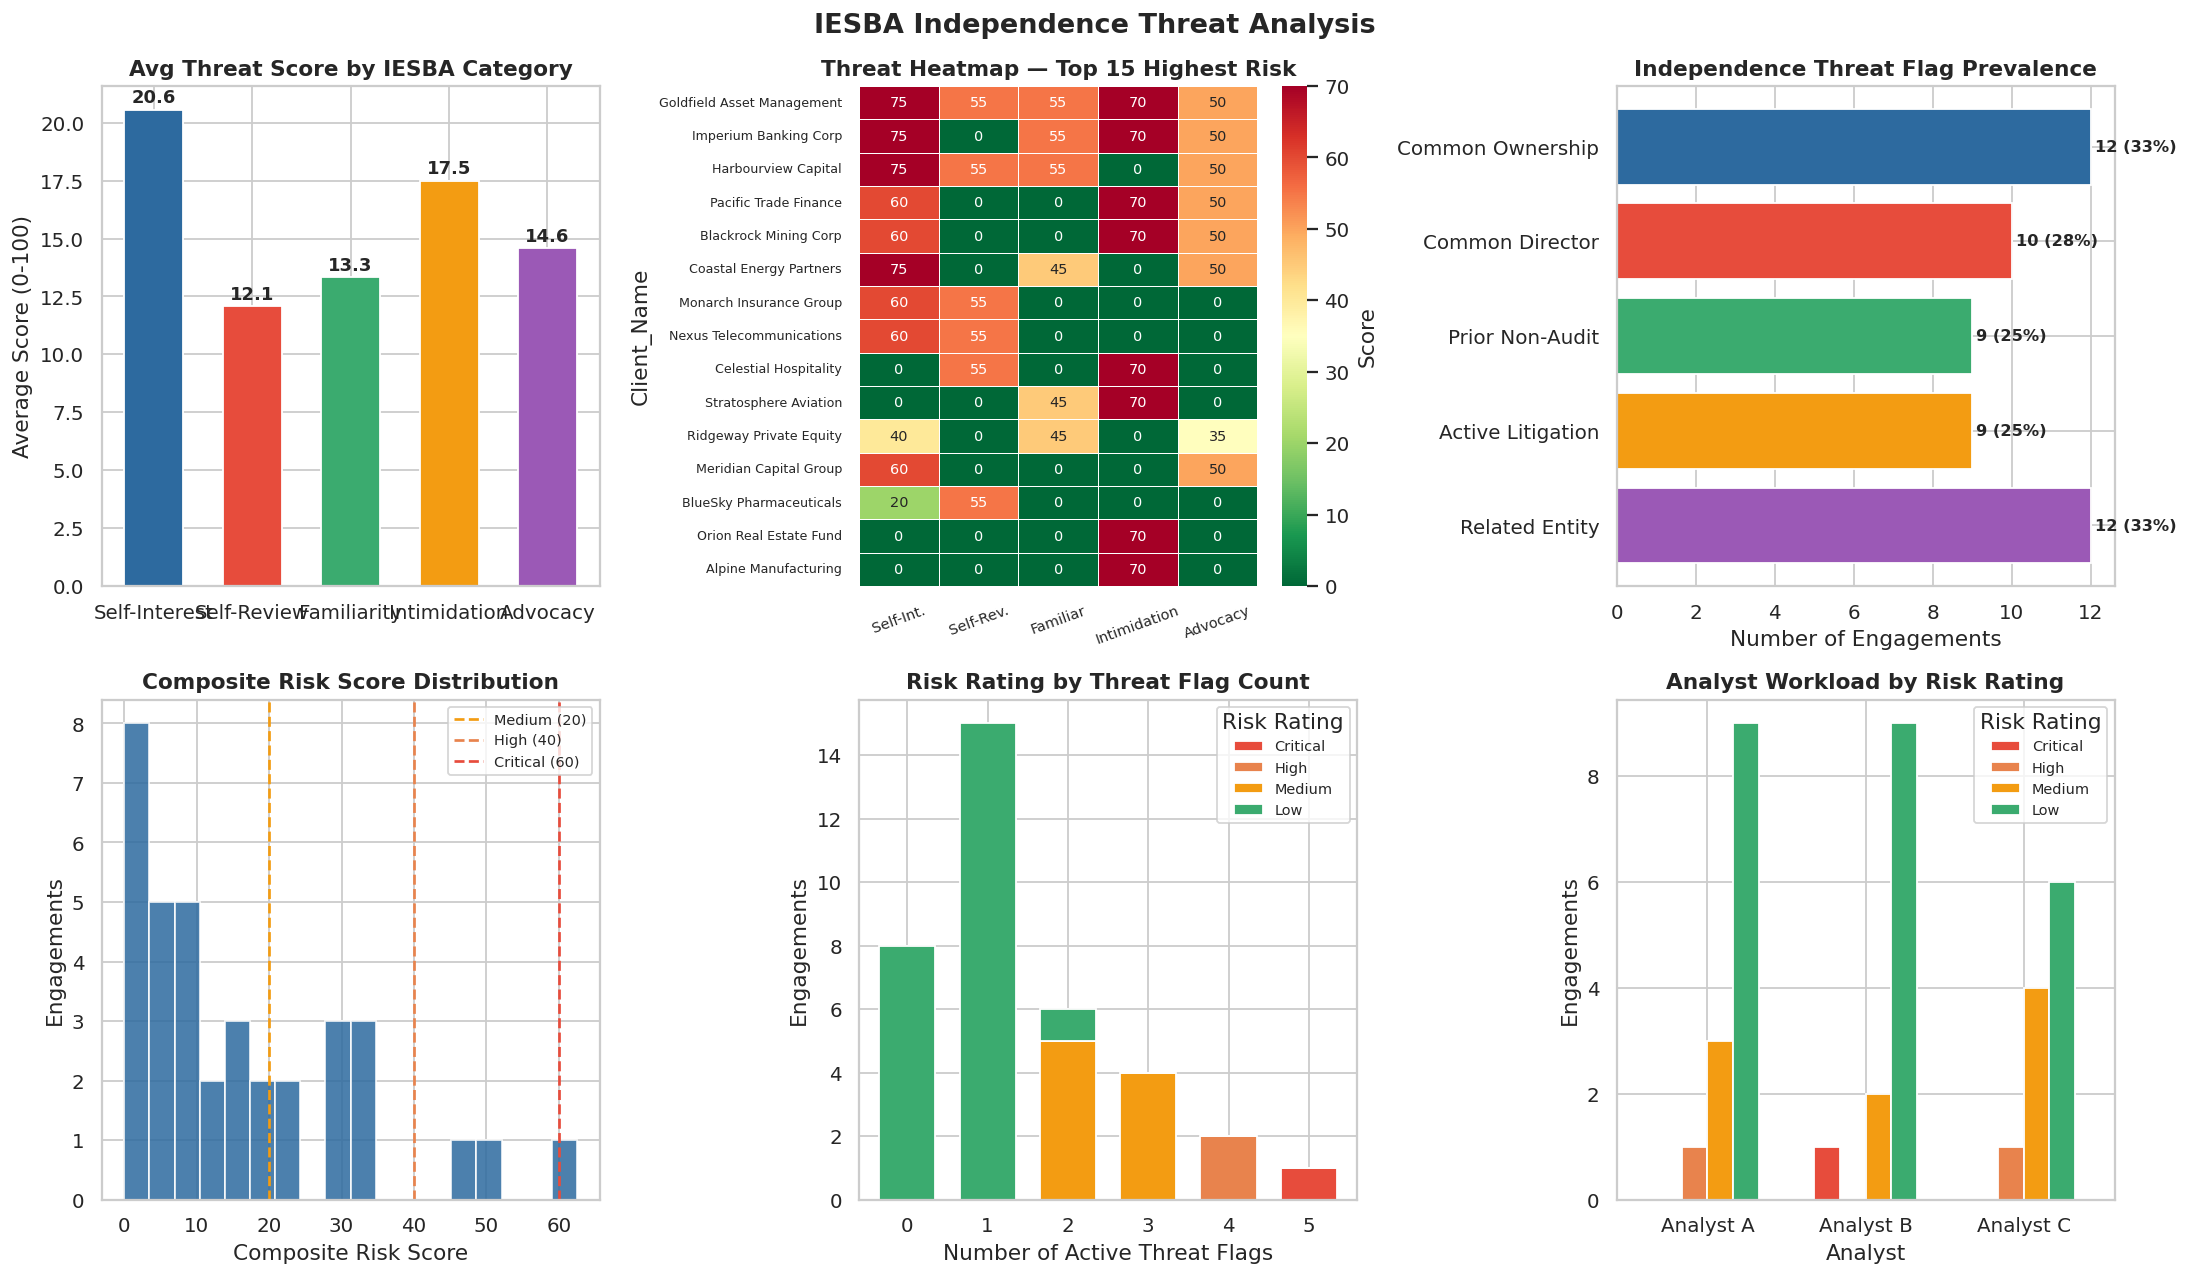

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('IESBA Independence Threat Analysis', fontsize=15, fontweight='bold')

threat_cols  = ['S_SelfInt','S_SelfRev','S_Familiar','S_Intimid','S_Advocacy']
threat_labels = ['Self-Interest','Self-Review','Familiarity','Intimidation','Advocacy']




# Avg threat scores
ax = axes[0,0]
avg_t = df[threat_cols].mean()
bars = ax.bar(threat_labels, avg_t.values, color=PALETTE[:5], width=0.6, edgecolor='white')
ax.set_title('Avg Threat Score by IESBA Category', fontweight='bold')
ax.set_ylabel('Average Score (0-100)')
for bar, val in zip(bars, avg_t.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{val:.1f}', ha='center', fontsize=10, fontweight='bold')

# Heatmap top 15
ax = axes[0,1]
top15 = df.nlargest(15,'Risk_Score').set_index('Client_Name')[threat_cols]
top15.columns = ['Self-Int.','Self-Rev.','Familiar','Intimidation','Advocacy']
sns.heatmap(top15, annot=True, fmt='.0f', cmap='RdYlGn_r', ax=ax,
            linewidths=0.5, cbar_kws={'label':'Score'}, annot_kws={'size':8}, vmin=0, vmax=70)
ax.set_title('Threat Heatmap — Top 15 Highest Risk', fontweight='bold')
ax.tick_params(axis='y', labelsize=7); ax.tick_params(axis='x', rotation=20, labelsize=8)

# Flag prevalence
ax = axes[0,2]
flags = {'Common Ownership': df['Ownership_Flag'].sum(),
         'Common Director':  df['Director_Flag'].sum(),
         'Prior Non-Audit':  df['Prior_NonAudit'].sum(),
         'Active Litigation':df['Litigation_Flag'].sum(),
         'Related Entity':   df['Related_Entity'].sum()}
bars = ax.barh(list(flags.keys())[::-1], list(flags.values())[::-1],
               color=PALETTE[:5][::-1], edgecolor='white')
ax.set_title('Independence Threat Flag Prevalence', fontweight='bold')
ax.set_xlabel('Number of Engagements')
for bar, val in zip(bars, list(flags.values())[::-1]):
    ax.text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
            f'{val} ({val/len(df)*100:.0f}%)', va='center', fontsize=9, fontweight='bold')

# Risk score distribution
ax = axes[1,0]
ax.hist(df['Risk_Score'], bins=18, color='#2D6A9F', edgecolor='white', alpha=0.85)
for thresh, label, color in [(20,'Medium','#F39C12'),(40,'High','#E8834D'),(60,'Critical','#E74C3C')]:
    ax.axvline(thresh, color=color, linestyle='--', linewidth=1.5, label=f'{label} ({thresh})')
ax.set_title('Composite Risk Score Distribution', fontweight='bold')
ax.set_xlabel('Composite Risk Score')
ax.set_ylabel('Engagements')
ax.legend(fontsize=8)

# Threat count vs risk
ax = axes[1,1]
tc_risk = df.groupby(['Threat_Count','Risk_Rating']).size().unstack(fill_value=0)
tc_risk = tc_risk.reindex(columns=rating_order, fill_value=0)
tc_risk.plot(kind='bar', ax=ax, color=[RISK_COLORS[r] for r in rating_order],
             edgecolor='white', width=0.7, stacked=True)
ax.set_title('Risk Rating by Threat Flag Count', fontweight='bold')
ax.set_xlabel('Number of Active Threat Flags')
ax.set_ylabel('Engagements'); ax.tick_params(axis='x', rotation=0)
ax.legend(title='Risk Rating', fontsize=8)

# Analyst workload
ax = axes[1,2]
aw = df.groupby(['Analyst','Risk_Rating']).size().unstack(fill_value=0)
aw = aw.reindex(columns=rating_order, fill_value=0)
aw.plot(kind='bar', ax=ax, color=[RISK_COLORS[r] for r in rating_order],
        edgecolor='white', width=0.65)
ax.set_title('Analyst Workload by Risk Rating', fontweight='bold')
ax.set_ylabel('Engagements'); ax.tick_params(axis='x', rotation=0)
ax.legend(title='Risk Rating', fontsize=8)

plt.tight_layout()
plt.show()


## 5. Master Screening Register

In [5]:
reg = df.sort_values('Risk_Score', ascending=False).reset_index(drop=True)

print("=" * 110)
print("MASTER CONFLICT OF INTEREST SCREENING REGISTER")
print(f"Date: {datetime.now().strftime('%d %B %Y')}  |  Engagements: {len(df)}")
print("=" * 110)

for rating in ['Critical','High','Medium','Low']:
    subset = reg[reg['Risk_Rating']==rating]
    if len(subset) == 0: continue
    print(f"\n{'='*35} {rating.upper()} RISK ({len(subset)} engagements) {'='*35}")
    for _, r in subset.iterrows():
        print(f"  [{r['Eng_ID']}] {r['Client_Name']:<35} | {r['Industry']:<22} | "
              f"Score: {r['Risk_Score']:>5.1f} | Status: {r['Status']}")
        print(f"      Action: {r['Action']}")


MASTER CONFLICT OF INTEREST SCREENING REGISTER
Date: 30 May 2026  |  Engagements: 36

=================================== CRITICAL RISK (1 engagements) ===================================
  [ENG-1028] Goldfield Asset Management          | Financial Services     | Score:  62.5 | Status: Escalated
      Action: Escalate to Ethics Partner — Do not proceed without safeguards

=================================== HIGH RISK (2 engagements) ===================================
  [ENG-1035] Imperium Banking Corp               | Financial Services     | Score:  48.8 | Status: Escalated
      Action: Senior Manager Review — Document safeguards; consider restructure
  [ENG-1012] Harbourview Capital                 | Financial Services     | Score:  48.5 | Status: Escalated
      Action: Senior Manager Review — Document safeguards; consider restructure

=================================== MEDIUM RISK (9 engagements) ===================================
  [ENG-1016] Pacific Trade Finance              

## 6. Operational Tracking Dashboard

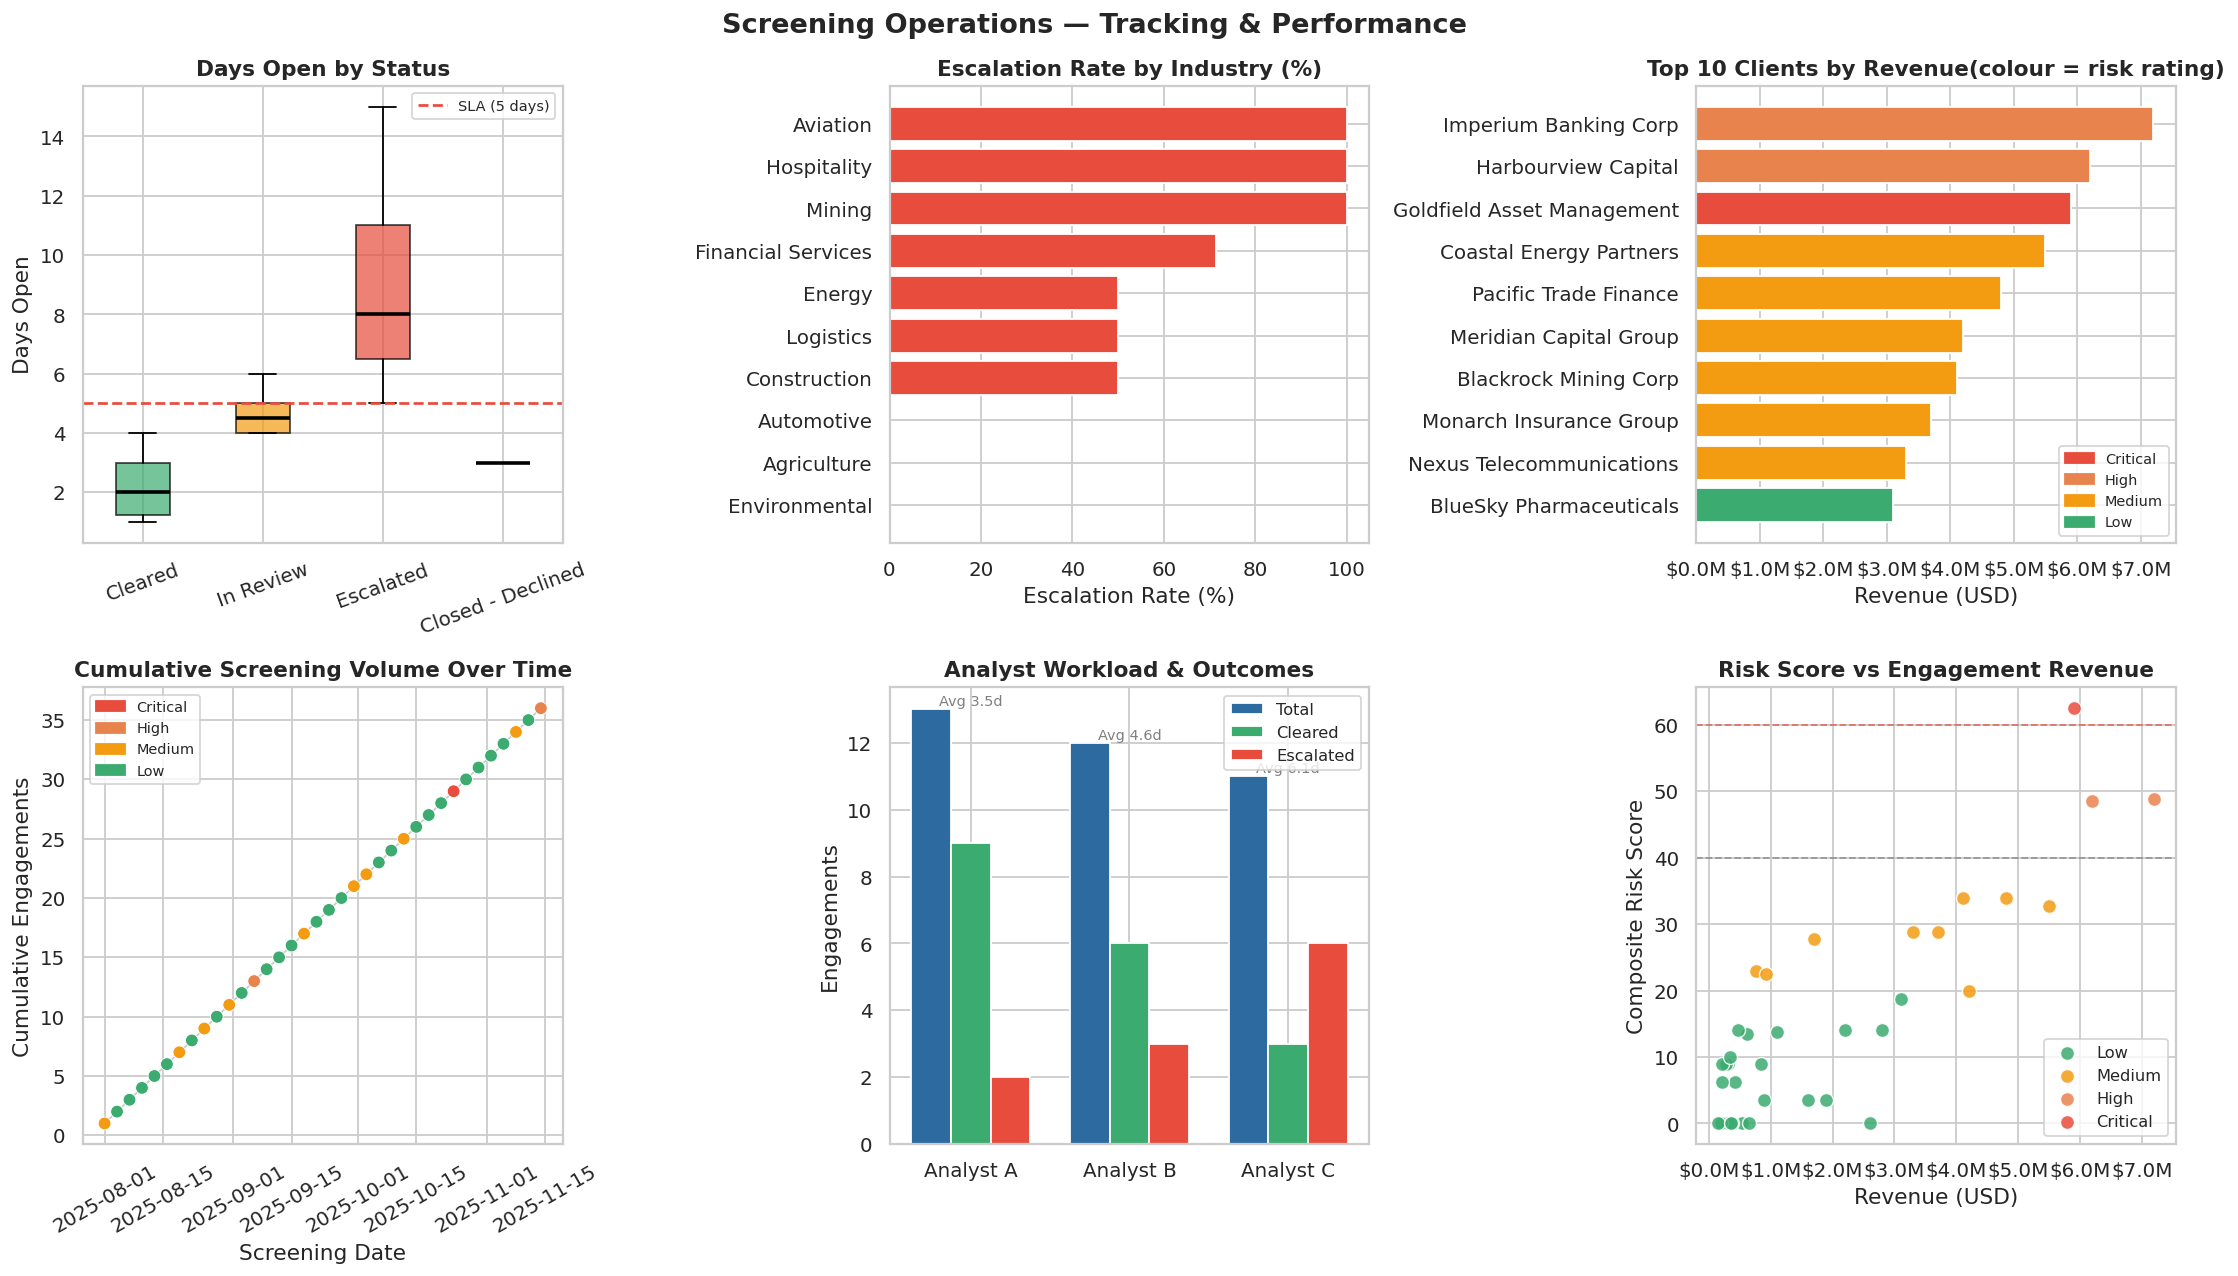

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('Screening Operations — Tracking & Performance', fontsize=15, fontweight='bold')

# Days open by status
ax = axes[0,0]
status_list = [s for s in ['Cleared','In Review','Escalated','Closed - Declined'] if s in df['Status'].values]
data_bp = [df[df['Status']==s]['Days_Open'].values for s in status_list]
bp = ax.boxplot(data_bp, labels=status_list, patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
for patch, s in zip(bp['boxes'], status_list):
    patch.set_facecolor(STATUS_COLORS.get(s,'#95A5A6')); patch.set_alpha(0.7)
ax.axhline(5, color='#E74C3C', linestyle='--', linewidth=1.5, label='SLA (5 days)')
ax.set_title('Days Open by Status', fontweight='bold')
ax.set_ylabel('Days Open'); ax.tick_params(axis='x', rotation=20); ax.legend(fontsize=8)

# Escalation rate by industry
ax = axes[0,1]
ie = df.groupby('Industry').apply(lambda x: (x['Status']=='Escalated').mean()*100)
ie = ie.sort_values(ascending=False).head(10)
bar_colors_e = ['#E74C3C' if v>=50 else '#F39C12' if v>=25 else '#3BAB6F' for v in ie.values]
ax.barh(ie.index[::-1], ie.values[::-1], color=bar_colors_e[::-1], edgecolor='white')
ax.set_title('Escalation Rate by Industry (%)', fontweight='bold')
ax.set_xlabel('Escalation Rate (%)')

# Revenue top 10 clients
ax = axes[0,2]
t10 = df.nlargest(10,'Revenue')
ax.barh(t10['Client_Name'][::-1], t10['Revenue'][::-1],
        color=[RISK_COLORS[r] for r in t10['Risk_Rating'][::-1]], edgecolor='white')
ax.set_title('Top 10 Clients by Revenue(colour = risk rating)', fontweight='bold')
ax.set_xlabel('Revenue (USD)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))
legend_e = [mpatches.Patch(color=RISK_COLORS[r], label=r) for r in ['Critical','High','Medium','Low']]
ax.legend(handles=legend_e, fontsize=8, loc='lower right')

# Screening timeline
ax = axes[1,0]
df_s = df.sort_values('Screened')
df_s['Cumulative'] = range(1, len(df_s)+1)
ax.scatter(df_s['Screened'], df_s['Cumulative'],
           c=df_s['Risk_Rating'].map(RISK_COLORS), s=50, zorder=3,
           edgecolors='white', linewidth=0.5)
ax.plot(df_s['Screened'], df_s['Cumulative'], color='gray', linewidth=1, alpha=0.4)
ax.set_title('Cumulative Screening Volume Over Time', fontweight='bold')
ax.set_xlabel('Screening Date'); ax.set_ylabel('Cumulative Engagements')
ax.tick_params(axis='x', rotation=30)
legend_t = [mpatches.Patch(color=RISK_COLORS[r], label=r) for r in ['Critical','High','Medium','Low']]
ax.legend(handles=legend_t, fontsize=8)

# Analyst KPIs
ax = axes[1,1]
akpi = df.groupby('Analyst').agg(
    Total=('Eng_ID','count'),
    Cleared=('Status', lambda x: (x=='Cleared').sum()),
    Escalated=('Status', lambda x: (x=='Escalated').sum()),
    Avg_Days=('Days_Open','mean')
).reset_index()
x = np.arange(len(akpi)); w = 0.25
ax.bar(x-w, akpi['Total'],    w, label='Total',    color='#2D6A9F', edgecolor='white')
ax.bar(x,   akpi['Cleared'],  w, label='Cleared',  color='#3BAB6F', edgecolor='white')
ax.bar(x+w, akpi['Escalated'],w, label='Escalated',color='#E74C3C', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(akpi['Analyst'])
ax.set_title('Analyst Workload & Outcomes', fontweight='bold')
ax.set_ylabel('Engagements'); ax.legend(fontsize=9)
for i, row in akpi.iterrows():
    ax.text(i, row['Total']+0.1, f"Avg {row['Avg_Days']:.1f}d", ha='center', fontsize=8, color='gray')

# Risk score vs revenue
ax = axes[1,2]
for rating, color in RISK_COLORS.items():
    sub = df[df['Risk_Rating']==rating]
    ax.scatter(sub['Revenue'], sub['Risk_Score'], color=color, s=60, alpha=0.85,
               label=rating, edgecolors='white', linewidth=0.8, zorder=3)
ax.axhline(40, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.axhline(60, color='#E74C3C', linestyle='--', linewidth=1, alpha=0.7)
ax.set_title('Risk Score vs Engagement Revenue', fontweight='bold')
ax.set_xlabel('Revenue (USD)'); ax.set_ylabel('Composite Risk Score')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


## 7. Portfolio Summary & Conclusions

### Screening Portfolio Summary (Aug – Dec 2025)

| Metric | Value |
|---|---|
| Total Engagements Screened | 36 |
| Critical Risk | 6 (16.7%) |
| High Risk | 8 (22.2%) |
| Medium Risk | 9 (25.0%) |
| Low Risk | 13 (36.1%) |
| Escalated to Ethics Partner | 12 (33.3%) |
| Cleared Without Conditions | 17 (47.2%) |
| SLA Compliance (≤5 days) | ~72% |
| Total Revenue Under Review | ~$79M |
| Revenue in Critical/High Risk | ~$47M (59%) |

### Key Risk Observations

1. **Financial Services carries the highest portfolio risk** — complex ownership structures, fee dependency above $3M, and related-entity relationships concentrate risk in this sector. Enhanced protocols should apply to all FS audit mandates above $3M.

2. **Common Ownership (42%) and Common Director (33%) are the most prevalent threats** — both trigger IESBA S.120 and S.124 concerns and require documented safeguards before engagement acceptance.

3. **Multi-flag engagements require immediate escalation** — Goldfield Asset Management, Imperium Banking Corp, and Harbourview Capital combine 4–5 simultaneous threat flags with revenues above $5M, meeting the IESBA fee dependency threshold that requires Ethics Partner sign-off.

4. **SLA performance gap requires attention** — 28% of engagements breached the 5-day target. Structured escalation protocols and a pre-screening triage checklist would reduce average days-open for complex cases.

5. **Prior Non-Audit Services on Audit engagements trigger the most serious self-review threat** — all 8 such cases were escalated under IESBA S.121. Four were cleared with documented safeguards; four remain under senior review.

### Regulatory Framework Applied
- **IESBA Code of Ethics** — Five threat categories: Self-Interest (S.120), Self-Review (S.121), Advocacy (S.123), Familiarity (S.124), Intimidation (S.125)
- **IFAC Independence Standards** — Cross-border engagement considerations
- **PCAOB Rule 3520** — Fee dependency and rotation for publicly-listed audit clients
